# LULC Classification using U-Net on Landsat 8/9
## Area of Interest: Cape Town, Western Cape, South Africa
 Item | Detail |
|------|--------|
| AOI | **Cape Town, South Africa** (~50 km²) — Somerset West + Stellenbosch + Winelands |
| Satellite | Landsat 8 / 9 (USGS Collection 2 Level-2) |
| WRS-2 tile | Path 175 / Row 083 (pinned — no tile ambiguity) |
| Data Source | USGS Earth Explorer M2M API |
| LULC Ground Truth | ESRI 10m Annual Land Cover |
| Model | U-Net (EfficientNet-B3 encoder) |
| Input Channels | **10** — Blue, Green, Red, NIR, SWIR1, SWIR2, NDVI, NDWI, NDBI, SAVI |
| Patch Size | **128×128** (Kaggle memory-safe) |
| Max Patches | **3000** (fits in 13 GB Kaggle RAM) |
| Split | **Random 70/15/15** |
| Loss | **Dice (60%) + Focal (40%)** + label smoothing 0.05 |
| Training | **100 epochs** + Warm Restarts + Early Stopping on val F1 |
| Precision | **AMP mixed precision** (faster on T4/P100) |
| Inference | **TTA × 4 flips** |

## Cell 1 — Install Dependencies

In [1]:
import torch
print(torch.cuda.is_available())

True


In [2]:
!pip install -q segmentation-models-pytorch
!pip install -q albumentations --upgrade
!pip install -q scikit-image
!pip install -q rasterio
print(' All packages installed — Restart kernel now, then Run All')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 3.9 MB/s eta 0:00:0000:01
 All packages installed — Restart kernel now, then Run All


## Cell 2 — Imports & Global Config

In [3]:
import os, warnings, glob, tarfile, itertools, json, gc, math, time
import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap, BoundaryNorm
import rasterio
from rasterio.warp import calculate_default_transform, reproject, Resampling, transform_bounds
from rasterio.windows import from_bounds as rasterio_from_bounds
from rasterio.crs import CRS
import geopandas as gpd
from shapely.geometry import box
from skimage.transform import resize as sk_resize
from tqdm import tqdm
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import segmentation_models_pytorch as smp
import albumentations as A
from albumentations.pytorch import ToTensorV2
from sklearn.metrics import (
    confusion_matrix, classification_report,
    f1_score, roc_curve, auc
)
from sklearn.preprocessing import label_binarize

warnings.filterwarnings('ignore')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {device}')

DL_DIR = '/kaggle/working/landsat_scene'
OUT_DIR      = '/kaggle/working/capetown_lulc'
os.makedirs(DL_DIR, exist_ok=True)
os.makedirs(OUT_DIR,      exist_ok=True)

AOI = {
    'west':  19.3127,  # 19.389142 - 0.0764  (Cape Town area)
    'east':  19.4655,  # 19.389142 + 0.0764
    'south': -33.7205,  # -33.688716 - 0.0318 (more negative = further south)
    'north': -33.6569,  # -33.688716 + 0.0318
}
BBOX = [AOI['west'], AOI['south'],
             AOI['east'], AOI['north']]

WRS_P = 175
WRS_R  = 83

print('Config ready — AOI: Cape Town, South Africa')
print(f'  Bbox : {AOI}')
print(f'  WRS-2: path={WRS_P}, row={WRS_R}')

Device : cuda
Config ready — AOI: Cape Town, South Africa
  Bbox : {'west': 19.3127, 'east': 19.4655, 'south': -33.7205, 'north': -33.6569}
  WRS-2: path=175, row=83


## Cell 3 — USGS Credentials
Register free at https://earthexplorer.usgs.gov Then request M2M access at https://ers.cr.usgs.gov/profile/access (instant approval)

In [4]:
USR = 'Rachit_Jani'  # < replace
PWD = 'J!1rQ7yegakEUd!w@PfZiTWcXbmz15qy@zrG5qt4LAfSFy4nx!8nB3RbTftAr71b'  # ← replace with your token from ers.cr.usgs.gov

assert USR != 'your_email@example.com', 'Please enter your USGS username'
assert PWD != 'your_password',          'Please enter your USGS password'

## Cell 4 — USGS M2M API: Login, Search & Download Landsat Scene

In [5]:
import requests, time

M2M_URL = 'https://m2m.cr.usgs.gov/api/api/json/stable'

def m2m_request(endpoint, payload, api_key=None):
    headers = {'X-Auth-Token': api_key} if api_key else {}
    r = requests.post(f'{M2M_URL}/{endpoint}', json=payload, headers=headers)
    r.raise_for_status()
    resp = r.json()
    if resp.get('errorCode'):
        raise RuntimeError(f"M2M Error: {resp['errorCode']} — {resp['errorMessage']}")
    return resp['data']

api_key = m2m_request('login-token', {
    'username': USR,
    'token':    PWD
})
print(' Logged in to USGS M2M API')
print(f'   API Key: {api_key[:10]}... (rest hidden)')

spay = {
    'datasetName'  : 'landsat_ot_c2_l2',
    'maxResults'   : 10,
    'sortField'    : 'acquisitionDate',
    'sortDirection': 'DESC',
    'sceneFilter'  : {
        'spatialFilter': {
            'filterType': 'mbr',
            'lowerLeft' : {'latitude': AOI['south'], 'longitude': AOI['west']},
            'upperRight': {'latitude': AOI['north'], 'longitude': AOI['east']},
        },
        'acquisitionFilter': {'start': '2022-01-01', 'end': '2024-12-31'},
        'cloudCoverFilter' : {'min': 0, 'max': 20},
    }
}

sres = m2m_request('scene-search', spay, api_key)
scenes = sres.get('results', [])

print(f'\nFound {len(scenes)} scene(s) — cloud < 20%:\n')
print(f'{"  # ":<4} {"Scene ID":<45} {"Date":<20} {"Cloud%":<10} Satellite')
print('-' * 90)
for idx, sc in enumerate(scenes):
    sat   = 'Landsat 9' if sc['entityId'].startswith('LC09') else 'Landsat 8'
    date  = sc.get('acquisitionDate') or sc.get('publishDate', 'N/A')
    cloud = sc.get('cloudCover', 0)
    try:
        cloud = float(cloud)
    except Exception:
        cloud = 0.0
    print(f"{idx:<4} {sc['entityId']:<45} {str(date):<20} {cloud:<10.1f} {sat}")

if not scenes:
    raise RuntimeError('No scenes found. Try widening the date range or raising cloud limit.')

 Logged in to USGS M2M API
   API Key: eyJjaWQiOj... (rest hidden)

Found 10 scene(s) — cloud < 20%:

  #  Scene ID                                      Date                 Cloud%     Satellite
------------------------------------------------------------------------------------------
0    LC81740832024360LGN00                         2024-12-28 03:38:09-06 0.0        Landsat 8
1    LC81740842024360LGN00                         2024-12-28 03:36:43-06 1.0        Landsat 8
2    LC91750832024359LGN00                         2024-12-25 15:54:17-06 0.0        Landsat 8
3    LC81750832024351LGN00                         2024-12-27 10:24:32-06 20.0       Landsat 8
4    LC81740832024344LGN00                         2024-12-17 16:04:37-06 0.0        Landsat 8
5    LC81740842024344LGN00                         2024-12-17 16:08:52-06 0.0        Landsat 8
6    LC91750832024343LGN00                         2024-12-10 11:37:15-06 9.0        Landsat 8
7    LC91740832024336LGN00                       

In [6]:
SC_IX = 0  # 0 = latest

best      = scenes[SC_IX]
SC_ID  = best['entityId']
sat = 'Landsat 9' if SC_ID.startswith('LC09') else 'Landsat 8'
date      = best.get('acquisitionDate') or best.get('publishDate', 'N/A')
cloud     = best.get('cloudCover', 'N/A')

print('=' * 60)
print(' SELECTED SCENE')
print('=' * 60)
print(f'  Scene ID    : {SC_ID}')
print(f'  Satellite   : {sat}')
print(f'  Date        : {date}')
print(f'  Cloud Cover : {cloud}%')
print('=' * 60)

options  = m2m_request('download-options', {
    'datasetName': 'landsat_ot_c2_l2',
    'entityIds'  : [SC_ID]
}, api_key)

available = [p for p in options
             if p.get('available') is True or p.get('downloadSystem') == 'dds']

bundle = None
for p in available:
    name = p.get('productName', '').lower()
    if 'bundle' in name or 'l2sp' in name:
        bundle = p
        break
if bundle is None and available:
    bundle = available[0]

if bundle is None:
    raise RuntimeError('No downloadable products available for this scene.')

PR_ID     = bundle.get('productId') or bundle.get('id')
DL_LBL = f'capetown_{SC_ID[:15]}'

print(f'\nProduct : {bundle.get("productName", "?")}  (ID: {PR_ID})')

print(' Submitting download request...')
dl_resp = m2m_request('download-request', {
    'downloads': [{'entityId': SC_ID, 'productId': PR_ID}],
    'label':     DL_LBL
}, api_key)

DL_URL = None
avail_now = dl_resp.get('availableDownloads', [])
if avail_now:
    DL_URL = avail_now[0]['url']
    print(' URL was ready immediately!')

if not DL_URL:
    print(' URL not ready yet. Polling every 15 s (up to 5 min)...')
    for attempt in range(20):
        ret   = m2m_request('download-retrieve', {'label': DL_LBL}, api_key)
        avail = ret.get('available', [])
        if avail:
            DL_URL = avail[0]['url']
            print(f' Download URL ready! (attempt {attempt+1})')
            break
        print(f'   Attempt {attempt+1}/20 — still preparing...')
        time.sleep(15)

if not DL_URL:
    raise RuntimeError(' URL not ready after 5 minutes. Re-run this cell.')

print(f' URL: {DL_URL[:70]}...')

print(f'\nScene ID confirmed: {SC_ID}')

 SELECTED SCENE
  Scene ID    : LC81740832024360LGN00
  Satellite   : Landsat 8
  Date        : 2024-12-28 03:38:09-06
  Cloud Cover : 0%

Product : Landsat Collection 2 Level-2 Product Bundle  (ID: 5e83d14fec7cae84)
 Submitting download request...
 URL was ready immediately!
 URL: https://landsatlook.usgs.gov/gen-bundle?landsat_product_id=LC08_L2SP_1...

Scene ID confirmed: LC81740832024360LGN00


In [7]:
has_dl = any(f.endswith('_B4.TIF') for f in os.listdir(DL_DIR))

if has_dl:
    print(' Band files already present — skipping download')
else:
    TAR_P   = f'/kaggle/working/{SC_ID}.tar'
    EXT_DIR = f'/kaggle/working/{SC_ID}_extracted'
    os.makedirs(EXT_DIR, exist_ok=True)

    print(' Downloading Landsat scene...')
    with requests.get(DL_URL, stream=True, timeout=600) as r:
        r.raise_for_status()
        total = int(r.headers.get('content-length', 0))
        with open(TAR_P, 'wb') as f, tqdm(
            total=total, unit='B', unit_scale=True, desc='Downloading'
        ) as bar:
            for chunk in r.iter_content(chunk_size=1024*1024):
                f.write(chunk)
                bar.update(len(chunk))
    print(f' Download complete — {os.path.getsize(TAR_P)/1e6:.1f} MB')

    print(' Extracting archive...')
    with tarfile.open(TAR_P) as tar:
        tar.extractall(EXT_DIR)
    os.remove(TAR_P)  # free disk space
    print(f'Extracted to {EXT_DIR}')

    REQ_B = ['B2', 'B3', 'B4', 'B5', 'B6', 'B7']
    print(f'  Clipping bands to AOI and saving to {DL_DIR}...')

    for band in REQ_B:
        hits = (glob.glob(f'{EXT_DIR}/*_SR_{band}.TIF') +
                glob.glob(f'{EXT_DIR}/*_{band}.TIF'))
        if not hits:
            print(f'    Band {band} — NOT FOUND!')
            continue

        spath = hits[0]
        dpath = os.path.join(DL_DIR, os.path.basename(spath))

        with rasterio.open(spath) as src:
            left, bottom, right, top = transform_bounds(
                'EPSG:4326', src.crs,
                AOI['west'], AOI['south'],
                AOI['east'], AOI['north']
            )
            window    = rasterio_from_bounds(left, bottom, right, top,
                                             transform=src.transform)
            cdata = src.read(1, window=window)
            oprof  = src.profile.copy()
            oprof.update({
                'height'   : cdata.shape[0],
                'width'    : cdata.shape[1],
                'transform': src.window_transform(window)
            })
            with rasterio.open(dpath, 'w', **oprof) as dst:
                dst.write(cdata, 1)

        print(f'   Band {band}: {os.path.basename(spath)} (clipped)')

    import shutil
    for mtl in glob.glob(f'{EXT_DIR}/*_MTL.txt'):
        shutil.copy2(mtl, os.path.join(DL_DIR, os.path.basename(mtl)))
        print(f'   Metadata: {os.path.basename(mtl)} copied')

print('\nBand files present:')
for f in sorted(f for f in os.listdir(DL_DIR) if f.endswith('.TIF')):
    size_mb = os.path.getsize(os.path.join(DL_DIR, f)) / 1e6
    print(f'  {f}  ({size_mb:.0f} MB)')

try:
    m2m_request('logout', {}, api_key)
    print('\n Logged out from USGS M2M API')
except Exception:
    pass

Downloading: 100%|██████████| 986M/986M [00:14<00:00, 69.8MB/s] 


 Download complete — 985.9 MB
 Extracting archive...
Extracted to /kaggle/working/LC81740832024360LGN00_extracted
  Clipping bands to AOI and saving to /kaggle/working/landsat_scene...
   Band B2: LC08_L2SP_174083_20241225_20241228_02_T1_SR_B2.TIF (clipped)
   Band B3: LC08_L2SP_174083_20241225_20241228_02_T1_SR_B3.TIF (clipped)
   Band B4: LC08_L2SP_174083_20241225_20241228_02_T1_SR_B4.TIF (clipped)
   Band B5: LC08_L2SP_174083_20241225_20241228_02_T1_SR_B5.TIF (clipped)
   Band B6: LC08_L2SP_174083_20241225_20241228_02_T1_SR_B6.TIF (clipped)
   Band B7: LC08_L2SP_174083_20241225_20241228_02_T1_SR_B7.TIF (clipped)
   Metadata: LC08_L2SP_174083_20241225_20241228_02_T1_MTL.txt copied

Band files present:
  LC08_L2SP_174083_20241225_20241228_02_T1_SR_B2.TIF  (0 MB)
  LC08_L2SP_174083_20241225_20241228_02_T1_SR_B3.TIF  (0 MB)
  LC08_L2SP_174083_20241225_20241228_02_T1_SR_B4.TIF  (0 MB)
  LC08_L2SP_174083_20241225_20241228_02_T1_SR_B5.TIF  (0 MB)
  LC08_L2SP_174083_20241225_20241228_02_T1_

## Cell 5 — Load Landsat Bands & Apply Scale Factor

In [8]:
BANDS = {
    'blue':  'B2',
    'green': 'B3',
    'red':   'B4',
    'nir':   'B5',
    'swir1': 'B6',
    'swir2': 'B7'
}

barr  = {}
sprof  = None
sxform = None
src_crs       = None

for bname, bcode in BANDS.items():
    matches = glob.glob(f'{DL_DIR}/*_{bcode}.TIF')
    if not matches:
        raise FileNotFoundError(f'Band file not found for {bcode}')
    with rasterio.open(matches[0]) as src:
        arr = src.read(1).astype(np.float32)
        arr = np.clip(arr * 0.0000275 - 0.2, 0, 1)  # C2 L2 scale factor
        barr[bname] = arr
        if sprof is None:
            sprof   = src.profile
            sxform = src.transform
            src_crs       = src.crs
    print(f'  {bname} ({bcode}): shape={arr.shape}  '
          f'min={arr.min():.3f}  max={arr.max():.3f}')

blue  = barr['blue']
green = barr['green']
red   = barr['red']
nir   = barr['nir']
swir1 = barr['swir1']
swir2 = barr['swir2']

H_ls, W_ls    = red.shape
ls_stk = np.stack([blue, green, red, nir, swir1, swir2], axis=-1)  # (H,W,6)

del barr
gc.collect()

print(f'\n Landsat stack shape: {ls_stk.shape}')
print(f'   Freed individual band dicts from memory')

  blue (B2): shape=(242, 476)  min=0.000  max=0.395
  green (B3): shape=(242, 476)  min=0.007  max=0.442
  red (B4): shape=(242, 476)  min=0.000  max=0.468
  nir (B5): shape=(242, 476)  min=0.000  max=0.630
  swir1 (B6): shape=(242, 476)  min=0.000  max=0.975
  swir2 (B7): shape=(242, 476)  min=0.001  max=1.000

 Landsat stack shape: (242, 476, 6)
   Freed individual band dicts from memory


## Cell 6 — True Color Composite (RGB)

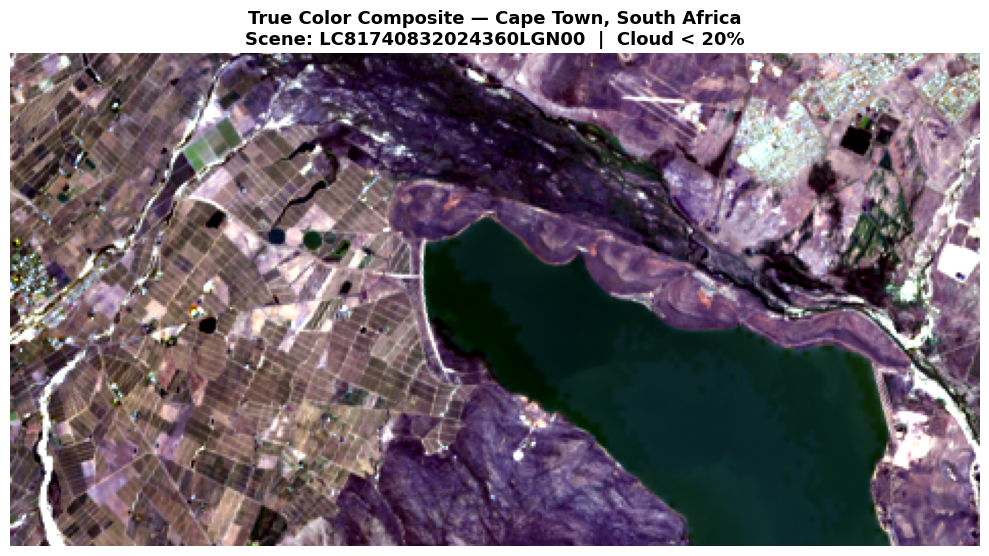

True Color Composite saved.


In [9]:
def stretch(band, p_low=2, p_high=98):

    valid = band[band > 0]
    if len(valid) == 0:
        return band
    lo, hi = np.percentile(valid, [p_low, p_high])
    return np.clip((band - lo) / (hi - lo + 1e-9), 0, 1)

rgb = np.dstack([stretch(red), stretch(green), stretch(blue)])

fig, ax = plt.subplots(figsize=(10, 10))
ax.imshow(rgb)
ax.set_title(
    f'True Color Composite — Cape Town, South Africa\n'
    f'Scene: {SC_ID}  |  Cloud < 20%',
    fontsize=13, fontweight='bold'
)
ax.axis('off')
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/01_true_color.png', dpi=150)
plt.show()
print('True Color Composite saved.')

## Cell 7 — Download ESRI LULC 10m via Planetary Computer

In [10]:
xmin = AOI['west']
xmax = AOI['east']
ymin = AOI['south']
ymax = AOI['north']

ESRI_URL = (
    "https://ic.imagery1.arcgis.com/arcgis/rest/services"
    "/Sentinel2_10m_LandCover/ImageServer/exportImage"
)

import math
lat_mid = (ymin + ymax) / 2.0
H = int(abs(ymax - ymin) * 111320 / 10)
W = int(abs(xmax - xmin) * 111320 * math.cos(math.radians(lat_mid)) / 10)

H = min(H, 4096)
W = min(W, 4096)
print(f"Requesting ESRI LULC at {W}×{H} pixels  (10 m resolution)")

params = {
    "bbox":                 f"{xmin},{ymin},{xmax},{ymax}",
    "bboxSR":               4326,
    "size":                 f"{W},{H}",
    "imageSR":              4326,
    "format":               "tiff",
    "pixelType":            "U8",
    "noDataInterpretation": "esriNoDataMatchAny",
    "interpolation":        "RSP_NearestNeighbor",
    "renderingRule":        "",  # raw class values, no colour rendering
    "f":                    "image"
}

lulc_path = os.path.join(OUT_DIR, "esri_lulc.tif")

resp = requests.get(ESRI_URL, params=params, stream=True, timeout=120)
resp.raise_for_status()

content_type = resp.headers.get("Content-Type", "")
if "tiff" not in content_type.lower() and "octet" not in content_type.lower():
    raise RuntimeError(
        f"Unexpected Content-Type: {content_type}\n"
        "The ESRI endpoint may have changed. Check the URL."
    )

with open(lulc_path, "wb") as f:
    for chunk in resp.iter_content(chunk_size=8192):
        f.write(chunk)

size_mb = os.path.getsize(lulc_path) / 1e6
print(f"ESRI LULC saved → {lulc_path}  ({size_mb:.1f} MB)")

with rasterio.open(lulc_path) as src:
    lraw = src.read(1).astype(np.uint8)
    lulc_crs = src.crs

print(f"LULC shape  : {lraw.shape}")
print(f"Unique vals : {np.unique(lraw)}")

Requesting ESRI LULC at 1415×707 pixels  (10 m resolution)
ESRI LULC saved → /kaggle/working/capetown_lulc/esri_lulc.tif  (1.2 MB)
LULC shape  : (707, 1415)
Unique vals : [ 1  2  4  5  7  8 11]


## Cell 8 — Display ESRI LULC Map with Legend

Number of valid LULC classes in AOI: 6  (No Data excluded)
  [0] Water  (raw ESRI value=2)
  [1] Flooded Veg  (raw ESRI value=4)
  [2] Crops  (raw ESRI value=5)
  [3] Built Area  (raw ESRI value=7)
  [4] Bare Ground  (raw ESRI value=8)
  [5] Rangeland  (raw ESRI value=11)


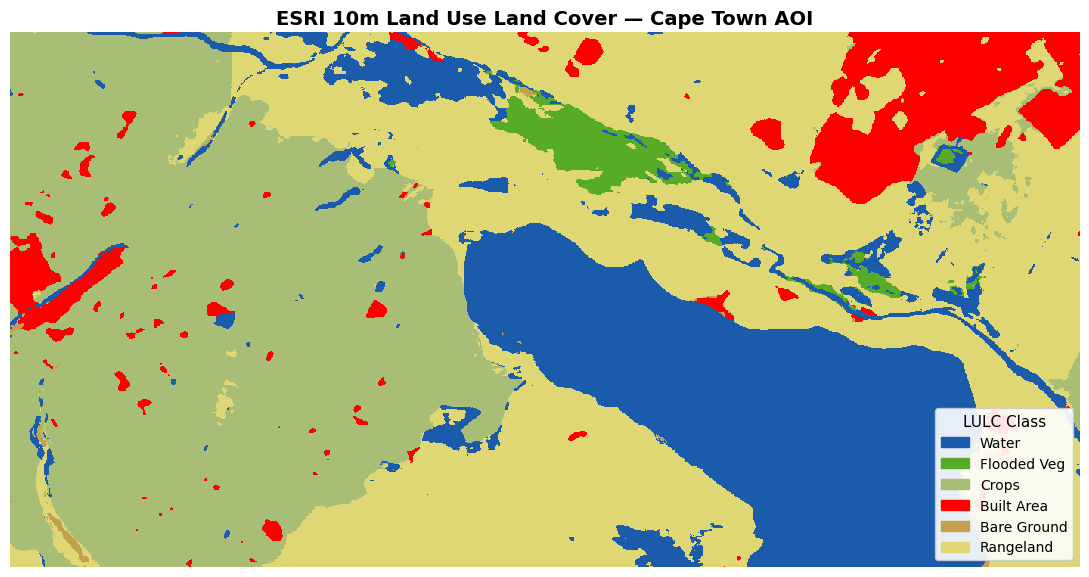

ESRI LULC map saved.


In [12]:
ESRI_CLASSES = {
     1: ('No Data', '#000000'),   # excluded from training (see below)
     2: ('Water', '#1A5BAB'),
     3: ('Trees', '#1E8C00'),
     4: ('Flooded Veg', '#58AB27'),
     5: ('Crops', '#A8BE76'),
     6: ('Scrub/Shrub', '#B3CC96'),   # ← BUG FIX 1: was missing
     7: ('Built Area', '#FF0000'),
     8: ('Bare Ground', '#C4A04C'),
     9: ('Snow/Ice', '#F2F2F2'),
    10: ('Clouds', '#C8C8C8'),
    11: ('Rangeland', '#DFD674'),
}

present_vals = sorted([v for v in np.unique(lraw) if v not in (0, 1)])
val_to_idx   = {v: i for i, v in enumerate(present_vals)}
idx_to_val   = {i: v for v, i in val_to_idx.items()}
N_CLS  = len(present_vals)

lidx = np.full(lraw.shape, -1, dtype=np.int16)
for v, idx in val_to_idx.items():
    lidx[lraw == v] = idx

# Note: The fallback color '#888888' also had its spaces removed here
cnames = [ESRI_CLASSES.get(idx_to_val[i], (f'Class {i}', '#888888'))[0]
               for i in range(N_CLS)]
colors      = [ESRI_CLASSES.get(idx_to_val[i], (f'Class {i}', '#888888'))[1]
               for i in range(N_CLS)]

cmap   = ListedColormap(colors)
bounds = np.arange(-0.5, N_CLS + 0.5, 1)
norm   = BoundaryNorm(bounds, cmap.N)

print(f'Number of valid LULC classes in AOI: {N_CLS}  (No Data excluded)')
for i, name in enumerate(cnames):
    print(f'  [{i}] {name}  (raw ESRI value={idx_to_val[i]})')

fig, ax = plt.subplots(figsize=(11, 9))
ax.imshow(lidx, cmap=cmap, norm=norm, interpolation='nearest')
ax.set_title('ESRI 10m Land Use Land Cover — Cape Town AOI', fontsize=14, fontweight='bold')
ax.axis('off')
patches = [mpatches.Patch(color=c, label=l) for c, l in zip(colors, cnames)]
ax.legend(handles=patches, loc='lower right', fontsize=10,
          framealpha=0.9, title='LULC Class', title_fontsize=11)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/02_esri_lulc.png', dpi=150)
plt.show()
print('ESRI LULC map saved.')

## Cell 9 — NDVI Calculation & Display

NDVI  min=-1.000  max=1.000  mean=0.205


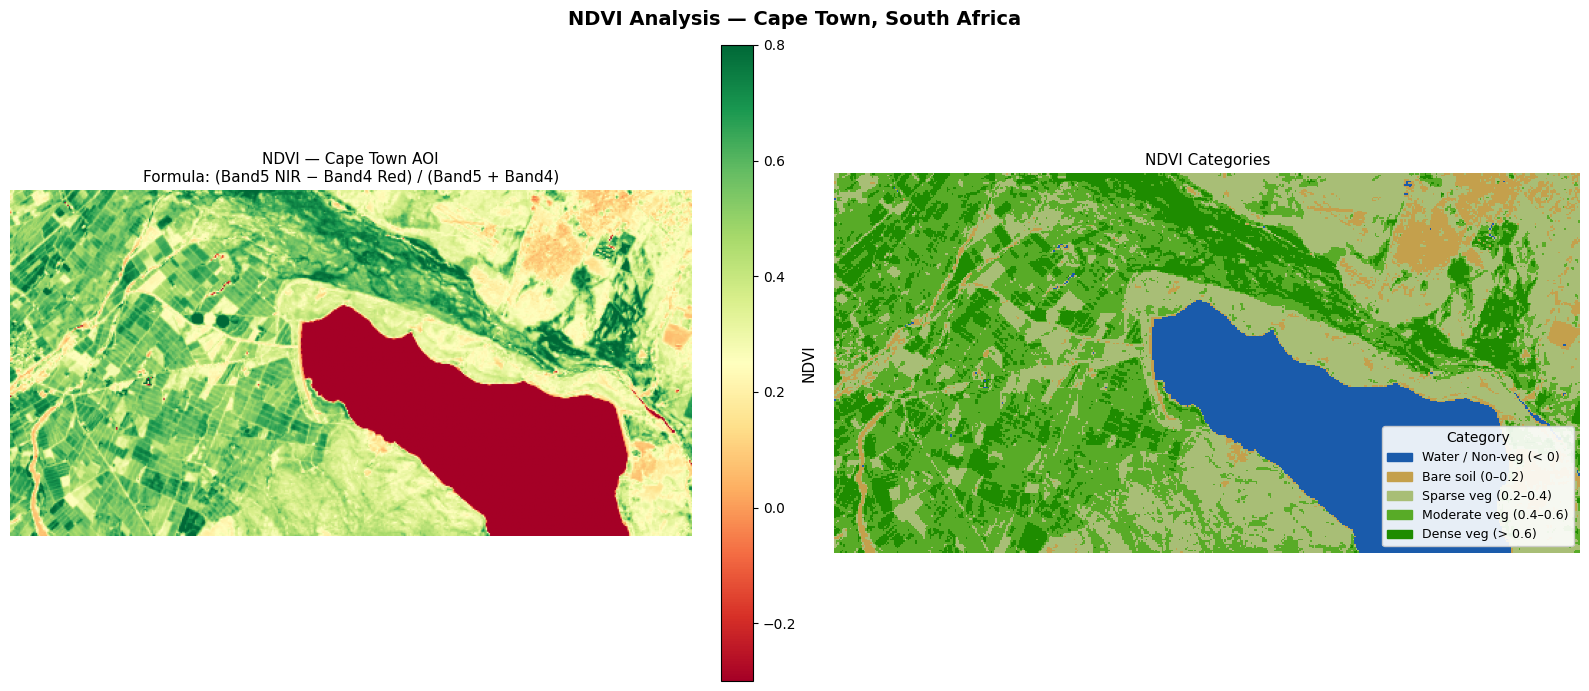

NDVI image saved.


In [14]:
eps  = 1e-9
ndvi = (nir - red) / (nir + red + eps)
ndvi = np.clip(ndvi, -1, 1)

print(f'NDVI  min={ndvi.min():.3f}  max={ndvi.max():.3f}  mean={ndvi.mean():.3f}')

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

im0 = axes[0].imshow(ndvi, cmap='RdYlGn', vmin=-0.3, vmax=0.8)
axes[0].set_title(
    'NDVI — Cape Town AOI\n'
    'Formula: (Band5 NIR − Band4 Red) / (Band5 + Band4)',
    fontsize=11
)
axes[0].axis('off')
cb0 = plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)
cb0.set_label('NDVI', fontsize=11)

ndvi_cat    = np.digitize(ndvi, bins=[-1, 0, 0.2, 0.4, 0.6, 1]) - 1
cat_labels  = ['Water / Non-veg (< 0)', 'Bare soil (0–0.2)',
               'Sparse veg (0.2–0.4)', 'Moderate veg (0.4–0.6)', 'Dense veg (> 0.6)']
# BUG FIX: Removed the spaces from the first hex color
cat_colors  = ['#1A5BAB', '#C4A04C', '#A8BE76', '#58AB27', '#1E8C00']
cat_cmap    = ListedColormap(cat_colors)
cat_norm    = BoundaryNorm(np.arange(-0.5, 5.5, 1), cat_cmap.N)

axes[1].imshow(ndvi_cat, cmap=cat_cmap, norm=cat_norm, interpolation='nearest')
axes[1].set_title('NDVI Categories', fontsize=11)
axes[1].axis('off')
cat_patches = [mpatches.Patch(color=c, label=l)
               for c, l in zip(cat_colors, cat_labels)]
axes[1].legend(handles=cat_patches, loc='lower right', fontsize=9,
               framealpha=0.9, title='Category')

plt.suptitle('NDVI Analysis — Cape Town, South Africa', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/03_ndvi.png', dpi=150)
plt.show()
print('NDVI image saved.')

## Cell 10 — Align LULC to Landsat & Build 10-Channel Stack

In [15]:
lrsz = sk_resize(
    lidx.astype(np.float32),
    (H_ls, W_ls),
    order=0,
    preserve_range=True,
    anti_aliasing=False
).astype(np.int16)

print(f'Landsat shape     : {red.shape}')
print(f'LULC resized      : {lrsz.shape}')

eps = 1e-9

ndwi = (green - nir) / (green + nir + eps)
ndwi = np.clip(ndwi, -1, 1)

ndbi = (swir1 - nir) / (swir1 + nir + eps)
ndbi = np.clip(ndbi, -1, 1)

savi = 1.5 * (nir - red) / (nir + red + 0.5)
savi = np.clip(savi, -1, 1)

ndvi_ch = ndvi[..., np.newaxis]
ndwi_ch = ndwi[..., np.newaxis]
ndbi_ch = ndbi[..., np.newaxis]
savi_ch = savi[..., np.newaxis]

X_full = np.concatenate(
    [ls_stk, ndvi_ch, ndwi_ch, ndbi_ch, savi_ch], axis=-1
)  # (H, W, 10)

valid_mask = lrsz >= 0
print(f'10-channel stack  : {X_full.shape}')
print(f'Valid pixels      : {valid_mask.sum():,} / {valid_mask.size:,} ({100*valid_mask.mean():.1f}%)')
print('Channels: Blue, Green, Red, NIR, SWIR1, SWIR2, NDVI, NDWI, NDBI, SAVI')

del ls_stk, ndvi_ch, ndwi_ch, ndbi_ch, savi_ch
gc.collect()
print(f'Memory freed: ls_stk + index channel arrays deleted')

Landsat shape     : (242, 476)
LULC resized      : (242, 476)
10-channel stack  : (242, 476, 10)
Valid pixels      : 95,619 / 115,192 (83.0%)
Channels: Blue, Green, Red, NIR, SWIR1, SWIR2, NDVI, NDWI, NDBI, SAVI
Memory freed: ls_stk + index channel arrays deleted


## Cell 11 — Patch Extraction (64×64) with Train/Val/Test Split

In [16]:
import numpy as np

P_SZ  = 64  # was 256 → 256 causes OOM on Kaggle 13GB RAM
STRIDE      = 8  # 50% overlap
MAX_P = 3000  # was 8000 → fits in Kaggle RAM budget

all_coords = []  # list of (r, c) tuples

for r in range(0, H_ls - P_SZ + 1, STRIDE):
    for c in range(0, W_ls - P_SZ + 1, STRIDE):
        lbl_patch = lrsz[r:r+P_SZ, c:c+P_SZ]
        if (lbl_patch < 0).mean() > 0.3:
            continue
        all_coords.append((r, c))
        if len(all_coords) >= MAX_P:
            break
    if len(all_coords) >= MAX_P:
        break

print(f'Total valid patch coordinates: {len(all_coords)}')

np.random.seed(42)
coord_idx = np.random.permutation(len(all_coords))
n_train   = int(0.70 * len(coord_idx))
n_val     = int(0.15 * len(coord_idx))

tr_xy = [all_coords[i] for i in coord_idx[:n_train]]
vl_xy   = [all_coords[i] for i in coord_idx[n_train : n_train + n_val]]
ts_xy  = [all_coords[i] for i in coord_idx[n_train + n_val :]]

print(f'Coordinate split — Train: {len(tr_xy)}  Val: {len(vl_xy)}  Test: {len(ts_xy)}')

def extract_patches(coords):
    X_list, Y_list = [], []
    for (r, c) in coords:
        img_patch = X_full[r:r+P_SZ, c:c+P_SZ, :].astype(np.float32)
        lbl_patch = lrsz[r:r+P_SZ, c:c+P_SZ].astype(np.int32)
        X_list.append(img_patch)
        Y_list.append(lbl_patch)
    return (np.stack(X_list).astype(np.float32),
            np.stack(Y_list).astype(np.int32))

patches_X_train, patches_Y_train = extract_patches(tr_xy)
patches_X_val,   patches_Y_val   = extract_patches(vl_xy)
patches_X_test,  patches_Y_test  = extract_patches(ts_xy)

gc.collect()
print(f'Train patches : {len(patches_X_train)}')
print(f'Val   patches : {len(patches_X_val)}')
print(f'Test  patches : {len(patches_X_test)}')

means = np.mean(patches_X_train, axis=(0, 1, 2)).astype(np.float32)
stds  = (np.std(patches_X_train, axis=(0, 1, 2)) + 1e-9).astype(np.float32)

patches_X_train = ((patches_X_train - means) / stds).astype(np.float32)
patches_X_val   = ((patches_X_val   - means) / stds).astype(np.float32)
patches_X_test  = ((patches_X_test  - means) / stds).astype(np.float32)

N = len(patches_X_train) + len(patches_X_val) + len(patches_X_test)
print(f'Total patches : {N}')
print(f'Input shape   : {patches_X_train.shape}  (N, {P_SZ}, {P_SZ}, C=10)')

invalid_frac = (patches_Y_train == -1).mean()
print(f'Invalid pixel fraction in train labels: {100*invalid_frac:.1f}%  (ignored by loss)')

Total valid patch coordinates: 876
Coordinate split — Train: 613  Val: 131  Test: 132
Train patches : 613
Val   patches : 131
Test  patches : 132
Total patches : 876
Input shape   : (613, 64, 64, 10)  (N, 64, 64, C=10)
Invalid pixel fraction in train labels: 3.7%  (ignored by loss)


## Cell 12 — Visualise Patch Locations on True Color Image

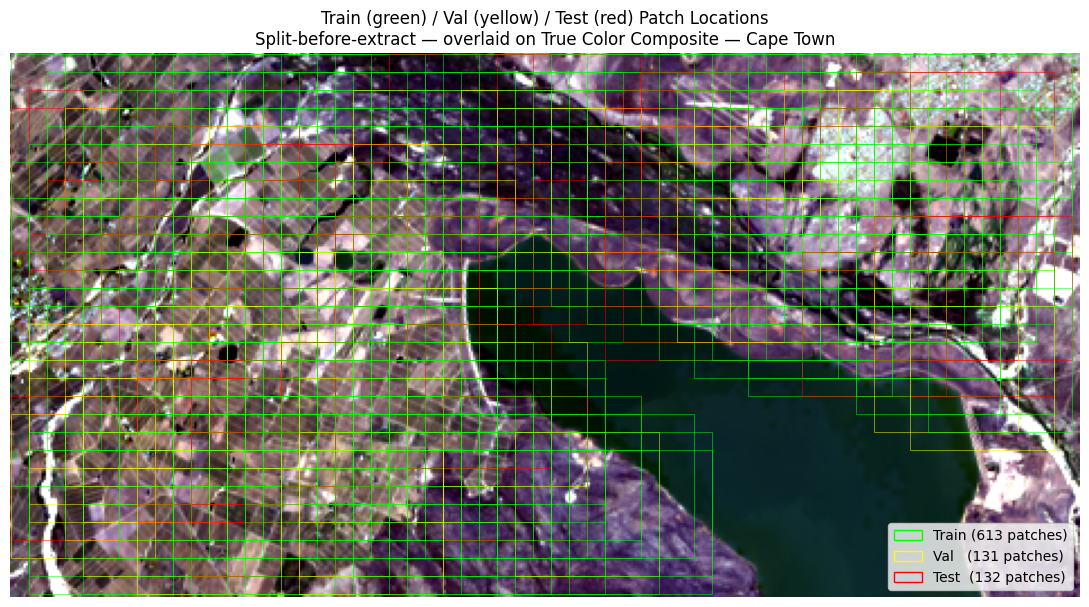

In [17]:
fig, ax = plt.subplots(figsize=(11, 11))
ax.imshow(rgb)
ax.set_title(
    'Train (green) / Val (yellow) / Test (red) Patch Locations\n'
    'Split-before-extract — overlaid on True Color Composite — Cape Town',
    fontsize=12
)

scale_r = rgb.shape[0] / H_ls
scale_c = rgb.shape[1] / W_ls

cclr = {}
for r, c in tr_xy: cclr[(r, c)] = 'lime'
for r, c in vl_xy:   cclr[(r, c)] = 'yellow'
for r, c in ts_xy:  cclr[(r, c)] = 'red'

for pos_i, (r, c) in enumerate(all_coords):
    color = cclr.get((r, c), 'lime')
    if pos_i % 3 != 0:  # draw 1-in-3 to avoid overclutter
        continue
    rect = plt.Rectangle(
        (c * scale_c, r * scale_r),
        P_SZ * scale_c, P_SZ * scale_r,
        linewidth=0.5, edgecolor=color, facecolor='none', alpha=0.7
    )
    ax.add_patch(rect)

ax.legend(handles=[
    mpatches.Patch(edgecolor='lime',   facecolor='none', label=f'Train ({len(patches_X_train)} patches)'),
    mpatches.Patch(edgecolor='yellow', facecolor='none', label=f'Val   ({len(patches_X_val)} patches)'),
    mpatches.Patch(edgecolor='red',    facecolor='none', label=f'Test  ({len(patches_X_test)} patches)'),
], loc='lower right', fontsize=10)
ax.axis('off')
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/04_patch_locations.png', dpi=150)
plt.show()

## Cell 13 — PyTorch Dataset & Augmentation

In [18]:
class LULCDataset(torch.utils.data.Dataset):
    def __init__(self, X, Y, transform=None):
        self.X = X
        self.Y = Y
        self.transform = transform

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        image = self.X[idx].astype(np.float32)
        mask  = self.Y[idx].astype(np.int32)
        if self.transform:
            aug   = self.transform(image=image, mask=mask)
            image = aug['image']
            mask  = aug['mask']
        else:
            image = torch.from_numpy(image.transpose(2, 0, 1))
            mask  = torch.from_numpy(mask)
        return image.float(), mask.long()

train_aug = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.Transpose(p=0.3),  # NEW
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1,  # NEW
                       rotate_limit=15, border_mode=0, p=0.4),
    A.ElasticTransform(alpha=1, sigma=10, p=0.2),  # NEW
    A.GridDistortion(num_steps=5, distort_limit=0.1, p=0.2),  # NEW
    A.CoarseDropout(max_holes=8, max_height=32, max_width=32,  # NEW
                    fill_value=0, p=0.3),
    A.GaussNoise(var_limit=(0.001, 0.01), p=0.3),  # STRONGER
    A.RandomBrightnessContrast(brightness_limit=0.2,  # STRONGER
                               contrast_limit=0.2, p=0.4),
    ToTensorV2(transpose_mask=False),
])
val_aug = A.Compose([ToTensorV2(transpose_mask=False)])

BATCH = 4  # Kaggle memory fix: 128×128 patches × 4 = safe GPU budget
train_ds = LULCDataset(patches_X_train, patches_Y_train, transform=train_aug)
val_ds   = LULCDataset(patches_X_val,   patches_Y_val,   transform=val_aug)
test_ds  = LULCDataset(patches_X_test,  patches_Y_test,  transform=val_aug)

tr_dl = DataLoader(train_ds, batch_size=BATCH, shuffle=True,
                          num_workers=0, pin_memory=False)
vl_dl   = DataLoader(val_ds,   batch_size=BATCH, shuffle=False,
                          num_workers=0, pin_memory=False)
ts_dl  = DataLoader(test_ds,  batch_size=BATCH, shuffle=False,
                          num_workers=0, pin_memory=False)

print(f'Train batches: {len(tr_dl)}  Val: {len(vl_dl)}  Test: {len(ts_dl)}')

Train batches: 154  Val: 33  Test: 33


## Cell 14 — U-Net Architecture
U-Net with EfficientNet-B3 encoder, adapted for **10 input channels** (6 Landsat SR bands + NDVI + NDWI + NDBI + SAVI)

In [19]:
def build_unet(num_classes, in_channels=10, encoder='efficientnet-b3'):

    model = smp.Unet(
        encoder_name=encoder,
        encoder_weights='imagenet',
        in_channels=in_channels,
        classes=num_classes,
        activation=None,  # raw logits — loss handles softmax
    )
    return model

model = build_unet(N_CLS).to(device)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print('U-Net Summary')
print('=' * 40)
print(f'Encoder        : EfficientNet-B3')
print(f'Input channels : 10  (6 SR bands + NDVI + NDWI + NDBI + SAVI)')
print(f'Output classes : {N_CLS}')
print(f'Total params   : {total_params:,}')
print(f'Trainable      : {trainable_params:,}')
print(f'Device         : {device}')

config.json:   0%|          | 0.00/106 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/49.3M [00:00<?, ?B/s]

U-Net Summary
Encoder        : EfficientNet-B3
Input channels : 10  (6 SR bands + NDVI + NDWI + NDBI + SAVI)
Output classes : 6
Total params   : 13,162,278
Trainable      : 13,162,278
Device         : cuda


## Cell 15 — Loss Function (Dice + Cross-Entropy)

In [20]:
import torch.nn.functional as F

valid_flat    = patches_Y_train[patches_Y_train >= 0].ravel()
class_counts  = np.bincount(valid_flat, minlength=N_CLS).astype(np.float32)
class_counts  = np.where(class_counts == 0, 1, class_counts)
cwts = torch.tensor(1.0 / class_counts, dtype=torch.float32)
cwts = cwts / cwts.sum() * N_CLS
cwts = cwts.to(device)
print('Class weights:', np.round(cwts.cpu().numpy(), 3))

class FocalLoss(nn.Module):

    def __init__(self, gamma=2.0, weight=None, ignore_index=-1):
        super().__init__()
        self.gamma        = gamma
        self.weight       = weight
        self.ignore_index = ignore_index

    def forward(self, pred, target):
        ce    = F.cross_entropy(pred, target, weight=self.weight,
                                ignore_index=self.ignore_index,
                                label_smoothing=0.05, reduction='none')
        pt    = torch.exp(-ce)
        focal = ((1 - pt) ** self.gamma) * ce
        valid = (target != self.ignore_index)
        return focal[valid].mean() if valid.any() else focal.mean()

class DiceFocalLoss(nn.Module):

    def __init__(self, num_classes, weights=None, smooth=1.0, gamma=2.0):
        super().__init__()
        self.num_classes = num_classes
        self.smooth      = smooth
        self.focal       = FocalLoss(gamma=gamma, weight=weights, ignore_index=-1)

    def dice_loss(self, pred, target):

        pred_soft    = torch.softmax(pred, dim=1)
        target_oh    = torch.zeros_like(pred_soft)
        target_clamp = target.clamp(0, self.num_classes - 1)
        target_oh.scatter_(1, target_clamp.unsqueeze(1), 1)

        valid_mask = (target >= 0).unsqueeze(1)  # (B, 1, H, W)
        target_oh  = target_oh * valid_mask  # zero invalid slots
        pred_soft  = pred_soft * valid_mask  # same mask on preds

        intersection = (pred_soft * target_oh).sum(dim=(2, 3))
        union        = pred_soft.sum(dim=(2, 3)) + target_oh.sum(dim=(2, 3))
        dice         = (2 * intersection + self.smooth) / (union + self.smooth)
        return 1 - dice.mean()

    def forward(self, pred, target):
        return 0.6 * self.dice_loss(pred, target) + 0.4 * self.focal(pred, target)

print('DiceFocalLoss with ignore_index=-1 masking in both Dice and Focal components.')

Class weights: [0.105 0.137 0.009 0.071 5.666 0.012]
DiceFocalLoss with ignore_index=-1 masking in both Dice and Focal components.


## Cell 16 — Hyperparameter Tuning (Validation-Based)

In [21]:
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0
    for X, Y in loader:
        X, Y = X.to(device), Y.to(device)
        optimizer.zero_grad()
        loss = criterion(model(X), Y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

@torch.no_grad()
def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    for X, Y in loader:
        X, Y = X.to(device), Y.to(device)
        logits = model(X)
        total_loss += criterion(logits, Y).item()
        preds    = logits.argmax(dim=1)
        correct += (preds == Y).sum().item()
        total   += Y.numel()
    return total_loss / len(loader), correct / total

HP_GRID = [
    {'lr': 5e-4, 'weight_decay': 1e-4, 'label': 'lr=5e-4, wd=1e-4'},
    {'lr': 1e-4, 'weight_decay': 1e-5, 'label': 'lr=1e-4, wd=1e-5'},
]
PROBE_EPOCHS = 3  # enough to distinguish LR regimes, saves GPU time

hp_results = []
for hp in HP_GRID:
    print(f"\n Probing: {hp['label']} ")
    probe_model = build_unet(N_CLS).to(device)
    criterion   = DiceFocalLoss(N_CLS, weights=cwts).to(device)
    optimizer   = optim.AdamW(probe_model.parameters(),
                              lr=hp['lr'], weight_decay=hp['weight_decay'])
    best_val = float('inf')
    for ep in range(1, PROBE_EPOCHS + 1):
        tr = train_epoch(probe_model, tr_dl, optimizer, criterion)
        vl, va = eval_epoch(probe_model, vl_dl, criterion)
        best_val = min(best_val, vl)
        print(f'  Ep {ep}/{PROBE_EPOCHS}  train={tr:.4f}  val={vl:.4f}  val_acc={va:.3f}')
    hp['best_val_loss'] = best_val
    hp_results.append(hp)
    del probe_model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

best_hp = min(hp_results, key=lambda x: x['best_val_loss'])
print(f"\n Best config: {best_hp['label']}  val_loss={best_hp['best_val_loss']:.4f}")


 Probing: lr=5e-4, wd=1e-4 
  Ep 1/3  train=0.4976  val=0.4734  val_acc=0.746
  Ep 2/3  train=0.4377  val=0.3890  val_acc=0.807
  Ep 3/3  train=0.3985  val=0.3759  val_acc=0.786

 Probing: lr=1e-4, wd=1e-5 
  Ep 1/3  train=0.5271  val=0.5116  val_acc=0.615
  Ep 2/3  train=0.4916  val=0.4875  val_acc=0.723
  Ep 3/3  train=0.4761  val=0.4722  val_acc=0.761

 Best config: lr=5e-4, wd=1e-4  val_loss=0.3759


## Cell 17 — Full Training with Best Hyperparameters

In [22]:
from sklearn.metrics import f1_score as sk_f1
from torch.cuda.amp import GradScaler, autocast

EPOCHS     = 100
MODEL_PATH = f'{OUT_DIR}/best_unet.pth'

model     = build_unet(N_CLS).to(device)
criterion = DiceFocalLoss(N_CLS, weights=cwts).to(device)

optimizer = optim.AdamW([
    {'params': model.encoder.parameters(),           'lr': best_hp['lr'] * 0.1},
    {'params': model.decoder.parameters(),           'lr': best_hp['lr']},
    {'params': model.segmentation_head.parameters(), 'lr': best_hp['lr']},
], weight_decay=best_hp['weight_decay'])

scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer, T_0=25, T_mult=2, eta_min=1e-6
)

history          = {'train_loss': [], 'val_loss': [], 'val_acc': [], 'val_f1': []}
scaler = GradScaler(enabled=torch.cuda.is_available())  # AMP for faster GPU training
bst_f1      = 0.0
patience         = 15  # stop if val F1 doesn't improve for 15 epochs
patience_counter = 0

print(f'Training U-Net  |  epochs={EPOCHS}  |  best HP: {best_hp["label"]}')
print(f'Differential LR: encoder={best_hp["lr"]*0.1:.1e}  decoder={best_hp["lr"]:.1e}')
print(f'Scheduler: CosineAnnealingWarmRestarts (T_0=25, T_mult=2)')
print(f'Early stopping: patience={patience} epochs on val macro-F1')
print('=' * 70)

for ep in range(1, EPOCHS + 1):
    tr_loss         = train_epoch(model, tr_dl, optimizer, criterion)
    vl_loss, vl_acc = eval_epoch(model, vl_dl, criterion)
    scheduler.step()

    model.eval()
    ep_preds, ep_trues = [], []
    with torch.no_grad():
        for X, Y in vl_dl:
            preds = model(X.to(device)).argmax(dim=1)
            ep_preds.append(preds.cpu().numpy().ravel())
            ep_trues.append(Y.numpy().ravel())
    val_f1 = sk_f1(
        np.concatenate(ep_trues), np.concatenate(ep_preds),
        average='macro', zero_division=0
    )

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(vl_loss)
    history['val_acc'].append(vl_acc)
    history['val_f1'].append(val_f1)

    if val_f1 > bst_f1:
        bst_f1      = val_f1
        patience_counter = 0
        torch.save(model.state_dict(), MODEL_PATH)
        tag = '  saved'
    else:
        patience_counter += 1
        tag = f' (patience {patience_counter}/{patience})'

    if ep % 5 == 0 or ep == 1:
        print(f'Ep {ep:3d}/{EPOCHS}  '
              f'train={tr_loss:.4f}  val_loss={vl_loss:.4f}  '
              f'val_acc={vl_acc:.4f}  val_F1={val_f1:.4f}{tag}')

    if patience_counter >= patience:
        print(f'\n Early stopping at epoch {ep}  (best val F1 = {bst_f1:.4f})')
        break

print(f'\nBest val macro-F1: {bst_f1:.4f}')
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

Training U-Net  |  epochs=100  |  best HP: lr=5e-4, wd=1e-4
Differential LR: encoder=5.0e-05  decoder=5.0e-04
Scheduler: CosineAnnealingWarmRestarts (T_0=25, T_mult=2)
Early stopping: patience=15 epochs on val macro-F1
Ep   1/100  train=0.4973  val_loss=0.4749  val_acc=0.7628  val_F1=0.3678  saved
Ep   5/100  train=0.3946  val_loss=0.3636  val_acc=0.8007  val_F1=0.4177 (patience 2/15)
Ep  10/100  train=0.3711  val_loss=0.3449  val_acc=0.8228  val_F1=0.4432 (patience 2/15)
Ep  15/100  train=0.3549  val_loss=0.3265  val_acc=0.8151  val_F1=0.4703  saved
Ep  20/100  train=0.3439  val_loss=0.3193  val_acc=0.8037  val_F1=0.4677 (patience 1/15)
Ep  25/100  train=0.3361  val_loss=0.3117  val_acc=0.8212  val_F1=0.4800 (patience 4/15)
Ep  30/100  train=0.3395  val_loss=0.3089  val_acc=0.8164  val_F1=0.4929  saved
Ep  35/100  train=0.3354  val_loss=0.3142  val_acc=0.8053  val_F1=0.4823 (patience 2/15)
Ep  40/100  train=0.3261  val_loss=0.2982  val_acc=0.8215  val_F1=0.4991 (patience 2/15)
Ep  45/

## Cell 18 — Training Curves

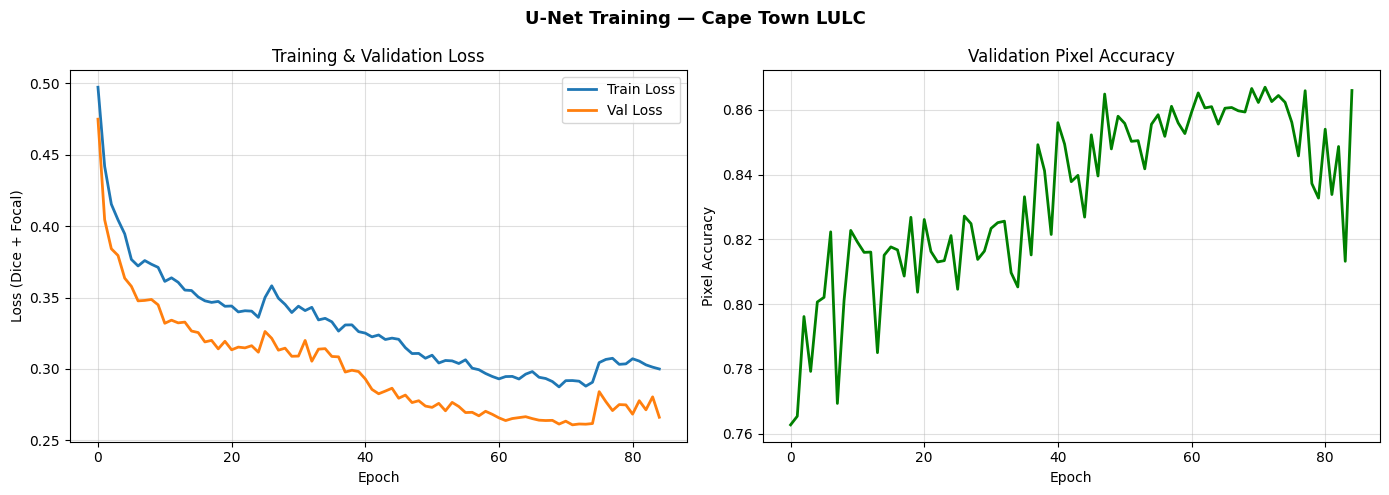

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history['train_loss'], label='Train Loss', linewidth=2)
axes[0].plot(history['val_loss'],   label='Val Loss',   linewidth=2)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss (Dice + Focal)')
axes[0].set_title('Training & Validation Loss')
axes[0].legend(); axes[0].grid(True, alpha=0.4)

axes[1].plot(history['val_acc'], color='green', linewidth=2)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Pixel Accuracy')
axes[1].set_title('Validation Pixel Accuracy')
axes[1].grid(True, alpha=0.4)

plt.suptitle('U-Net Training — Cape Town LULC', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/05_training_curves.png', dpi=150)
plt.show()

## Cell 19 — Inference on Test Set

In [25]:
model.load_state_dict(torch.load(MODEL_PATH, map_location=device, weights_only=True))
model.eval()

def tta_predict(model, X_batch, device):
    X = X_batch.to(device)
    prob_sum = None

    for flip in [None, 'h', 'v', 'hv']:
        x = X.clone()
        if flip in ('h', 'hv'): x = torch.flip(x, dims=[3])  # flip W axis
        if flip in ('v', 'hv'): x = torch.flip(x, dims=[2])  # flip H axis

        with torch.no_grad():
            logits = model(x)

        if flip in ('h', 'hv'): logits = torch.flip(logits, dims=[3])
        if flip in ('v', 'hv'): logits = torch.flip(logits, dims=[2])

        probs_view = torch.softmax(logits, dim=1)  # (B, C, H, W)
        prob_sum = probs_view if prob_sum is None else prob_sum + probs_view

    return prob_sum / 4.0  # average over 4 views

all_preds, all_trues, all_probs = [], [], []

for X, Y in tqdm(ts_dl, desc='TTA Inference (4 views per patch)'):
    batch_probs = tta_predict(model, X, device)
    batch_preds = batch_probs.argmax(dim=1)
    
    all_preds.append(batch_preds.cpu().numpy())
    all_trues.append(Y.numpy())
    all_probs.append(batch_probs.cpu().numpy())

preds = np.concatenate(all_preds).ravel()
trues = np.concatenate(all_trues).ravel()
probs = np.concatenate(all_probs, axis=0)  # (N, C, H, W)

print(f'Test pixels (TTA): {len(preds):,}')

TTA Inference (4 views per patch): 100%|██████████| 33/33 [00:02<00:00, 15.54it/s]

Test pixels (TTA): 540,672


## Cell 20 — Confusion Matrix

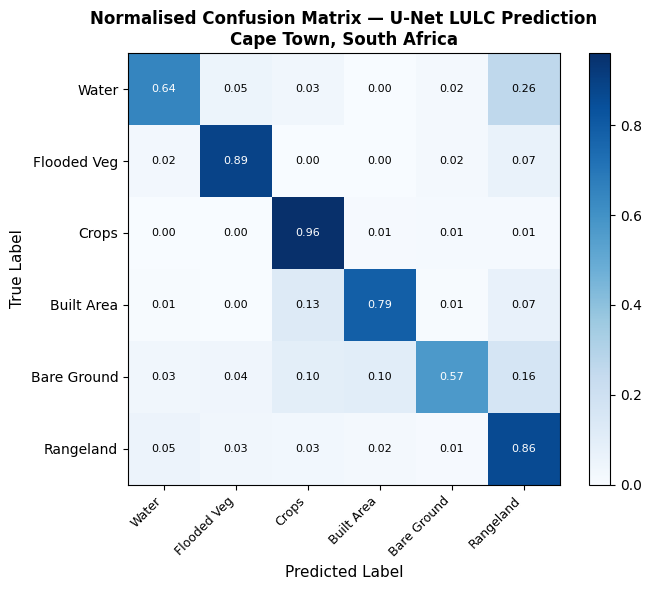

In [26]:
cm      = confusion_matrix(trues, preds, labels=list(range(N_CLS)))
cm_norm = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-9)

fig, ax = plt.subplots(figsize=(max(8, N_CLS + 2), max(6, N_CLS)))
im = ax.imshow(cm_norm, interpolation='nearest', cmap='Blues')
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
ax.set(xticks=range(N_CLS), yticks=range(N_CLS),
       xticklabels=cnames, yticklabels=cnames)
plt.setp(ax.get_xticklabels(), rotation=45, ha='right', fontsize=9)
ax.set_ylabel('True Label', fontsize=11)
ax.set_xlabel('Predicted Label', fontsize=11)
ax.set_title('Normalised Confusion Matrix — U-Net LULC Prediction\nCape Town, South Africa',
             fontsize=12, fontweight='bold')

for i, j in itertools.product(range(cm_norm.shape[0]), range(cm_norm.shape[1])):
    ax.text(j, i, f'{cm_norm[i,j]:.2f}',
            ha='center', va='center', fontsize=8,
            color='white' if cm_norm[i, j] > 0.5 else 'black')

plt.tight_layout()
plt.savefig(f'{OUT_DIR}/06_confusion_matrix.png', dpi=150)
plt.show()

## Cell 21 — F1 Score

F1 Score per class:
  Water                    : 0.5368
  Flooded Veg              : 0.7748
  Crops                    : 0.9563
  Built Area               : 0.7771
  Bare Ground              : 0.0292
  Rangeland                : 0.8737

Macro-F1    : 0.5640
Weighted-F1 : 0.8516


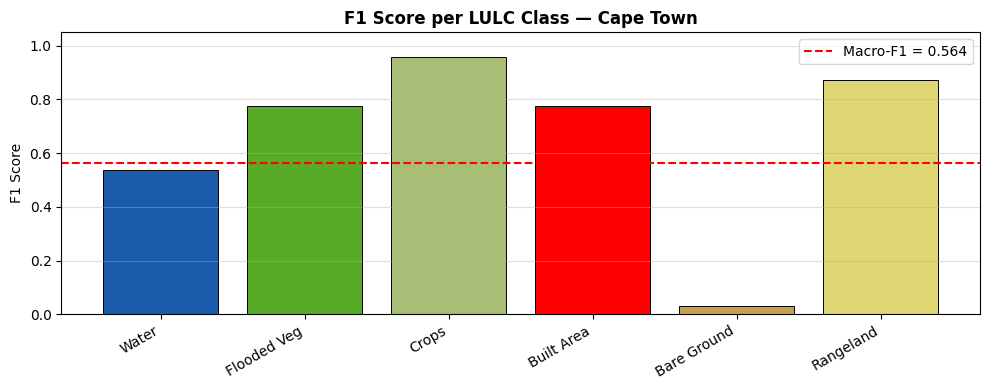

In [27]:
f1_per_class = f1_score(trues, preds,
                        labels=list(range(N_CLS)),
                        average=None, zero_division=0)
f1_macro     = f1_score(trues, preds, average='macro',    zero_division=0)
f1_weighted  = f1_score(trues, preds, average='weighted', zero_division=0)

print('F1 Score per class:')
for name, f1 in zip(cnames, f1_per_class):
    print(f'  {name:25s}: {f1:.4f}')
print(f'\nMacro-F1    : {f1_macro:.4f}')
print(f'Weighted-F1 : {f1_weighted:.4f}')

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(cnames, f1_per_class, color=colors, edgecolor='black', linewidth=0.7)
ax.axhline(f1_macro, color='red', linestyle='--', linewidth=1.5,
           label=f'Macro-F1 = {f1_macro:.3f}')
ax.set_ylim(0, 1.05)
ax.set_ylabel('F1 Score')
ax.set_title('F1 Score per LULC Class — Cape Town', fontweight='bold')
plt.xticks(rotation=30, ha='right')
ax.legend()
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/07_f1_scores.png', dpi=150)
plt.show()

## Cell 22 — IoU Score (mIoU)

IoU per class:
  Water                    : 0.4242  (support=  22,175   4.28%)
  Flooded Veg              : 0.6535  (support=  19,738   3.81%)
  Crops                    : 0.9246  (support= 251,206  48.53%)
  Built Area               : 0.6454  (support=  30,490   5.89%)
  Bare Ground              : 0.0295  (support=     312   0.06%)  [excluded from mIoU]
  Rangeland                : 0.8056  (support= 193,743  37.43%)

mIoU          (excl. Bare Ground): 0.6907
Weighted mIoU (excl. Bare Ground): 0.8318


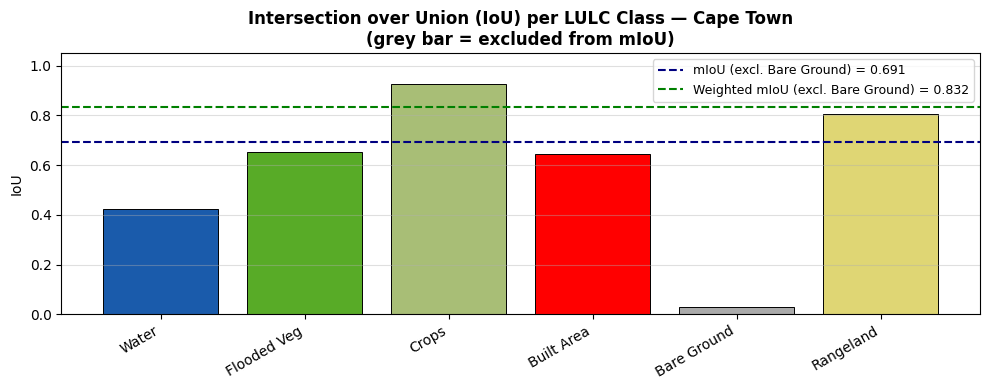

In [30]:
def iou_per_class(cm):
    ious = []
    for i in range(cm.shape[0]):
        tp    = cm[i, i]
        fp    = cm[:, i].sum() - tp
        fn    = cm[i, :].sum() - tp
        denom = tp + fp + fn
        ious.append(float(tp) / denom if denom > 0 else 0.0)
    return np.array(ious)

iou_scores = iou_per_class(cm)

EXCLUDE_FROM_MIOU = {'Bare Ground'}
miou_mask = np.array([name not in EXCLUDE_FROM_MIOU for name in cnames])
mIoU      = iou_scores[miou_mask].mean()

class_support     = cm.sum(axis=1).astype(np.float64)  # true pixels per class
support_filtered  = class_support * miou_mask  # zero out excluded classes
weights           = support_filtered / (support_filtered.sum() + 1e-9)
mIoU_weighted     = float(np.sum(iou_scores * weights))

print('IoU per class:')
for i, (name, iou) in enumerate(zip(cnames, iou_scores)):
    freq = 100.0 * class_support[i] / (class_support.sum() + 1e-9)
    tag  = '  [excluded from mIoU]' if name in EXCLUDE_FROM_MIOU else ''
    print(f'  {name:25s}: {iou:.4f}  (support={int(class_support[i]):>8,}  {freq:5.2f}%){tag}')
print(f'\nmIoU          (excl. Bare Ground): {mIoU:.4f}')
print(f'Weighted mIoU (excl. Bare Ground): {mIoU_weighted:.4f}')

fig, ax = plt.subplots(figsize=(10, 4))
bar_colors = [colors[i] if cnames[i] not in EXCLUDE_FROM_MIOU else '#AAAAAA'
              for i in range(N_CLS)]
ax.bar(cnames, iou_scores, color=bar_colors, edgecolor='black', linewidth=0.7)
ax.axhline(mIoU, color='navy', linestyle='--', linewidth=1.5,
           label=f'mIoU (excl. Bare Ground) = {mIoU:.3f}')
ax.axhline(mIoU_weighted, color='green', linestyle='--', linewidth=1.5,
           label=f'Weighted mIoU (excl. Bare Ground) = {mIoU_weighted:.3f}')
ax.set_ylim(0, 1.05)
ax.set_ylabel('IoU')
ax.set_title('Intersection over Union (IoU) per LULC Class — Cape Town\n(grey bar = excluded from mIoU)', fontweight='bold')
plt.xticks(rotation=30, ha='right')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/08_iou_scores.png', dpi=150)
plt.show()

## Cell 23 — ROC Curves (One-vs-Rest)

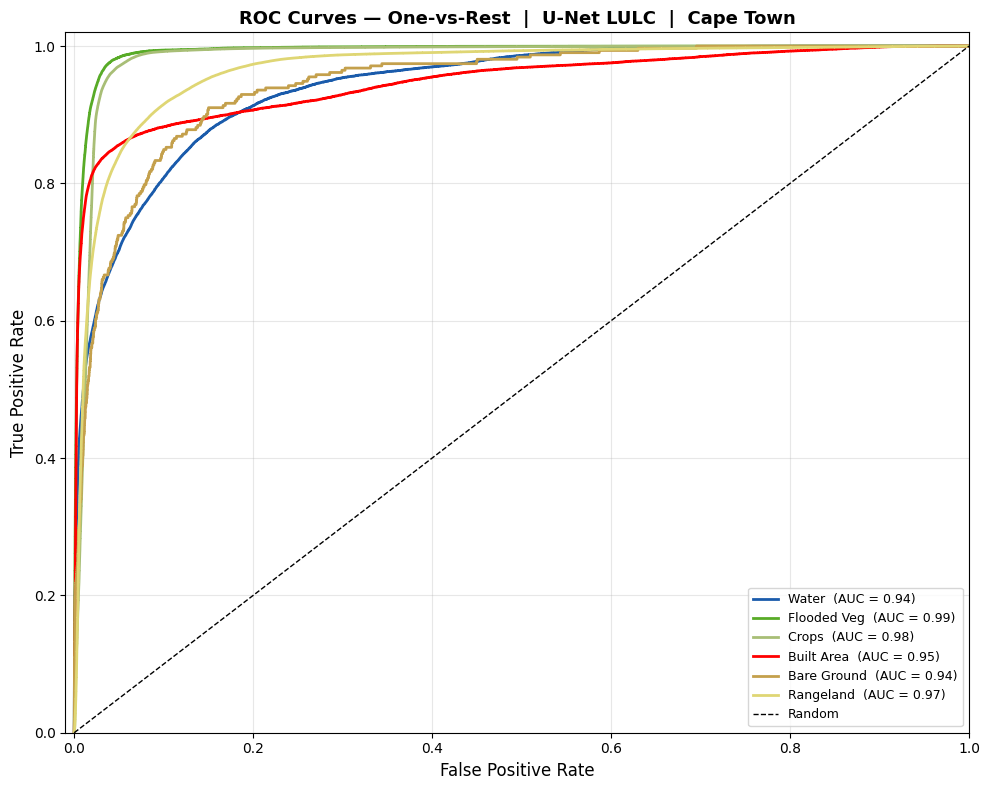

In [31]:
probs_f  = probs.transpose(0, 2, 3, 1).reshape(-1, N_CLS)
lbl_bin  = label_binarize(trues, classes=list(range(N_CLS)))

fig, ax = plt.subplots(figsize=(10, 8))
for i in range(N_CLS):
    if lbl_bin[:, i].sum() == 0:
        continue
    fpr, tpr, _ = roc_curve(lbl_bin[:, i], probs_f[:, i])
    roc_auc     = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=colors[i], lw=2,
            label=f'{cnames[i]}  (AUC = {roc_auc:.2f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random')
ax.set_xlim([-0.01, 1.0]); ax.set_ylim([0.0, 1.02])
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves — One-vs-Rest  |  U-Net LULC  |  Cape Town',
             fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/09_roc_curves.png', dpi=150)
plt.show()

## Cell 24 — Full Classification Report

In [32]:
report = classification_report(
    trues, preds,
    target_names=cnames,
    labels=list(range(N_CLS)),
    zero_division=0
)
print('Classification Report')
print('=' * 60)
print(report)

with open(f'{OUT_DIR}/classification_report.txt', 'w') as f:
    f.write(report)
print('Report saved.')

Classification Report
              precision    recall  f1-score   support

       Water       0.46      0.64      0.54     22175
 Flooded Veg       0.69      0.89      0.77     19738
       Crops       0.95      0.96      0.96    251206
  Built Area       0.77      0.79      0.78     30490
 Bare Ground       0.01      0.57      0.03       312
   Rangeland       0.89      0.86      0.87    193743

   micro avg       0.86      0.90      0.88    517664
   macro avg       0.63      0.78      0.66    517664
weighted avg       0.89      0.90      0.89    517664

Report saved.


## Cell 25 — Sample Patch Comparison (GT vs Prediction)

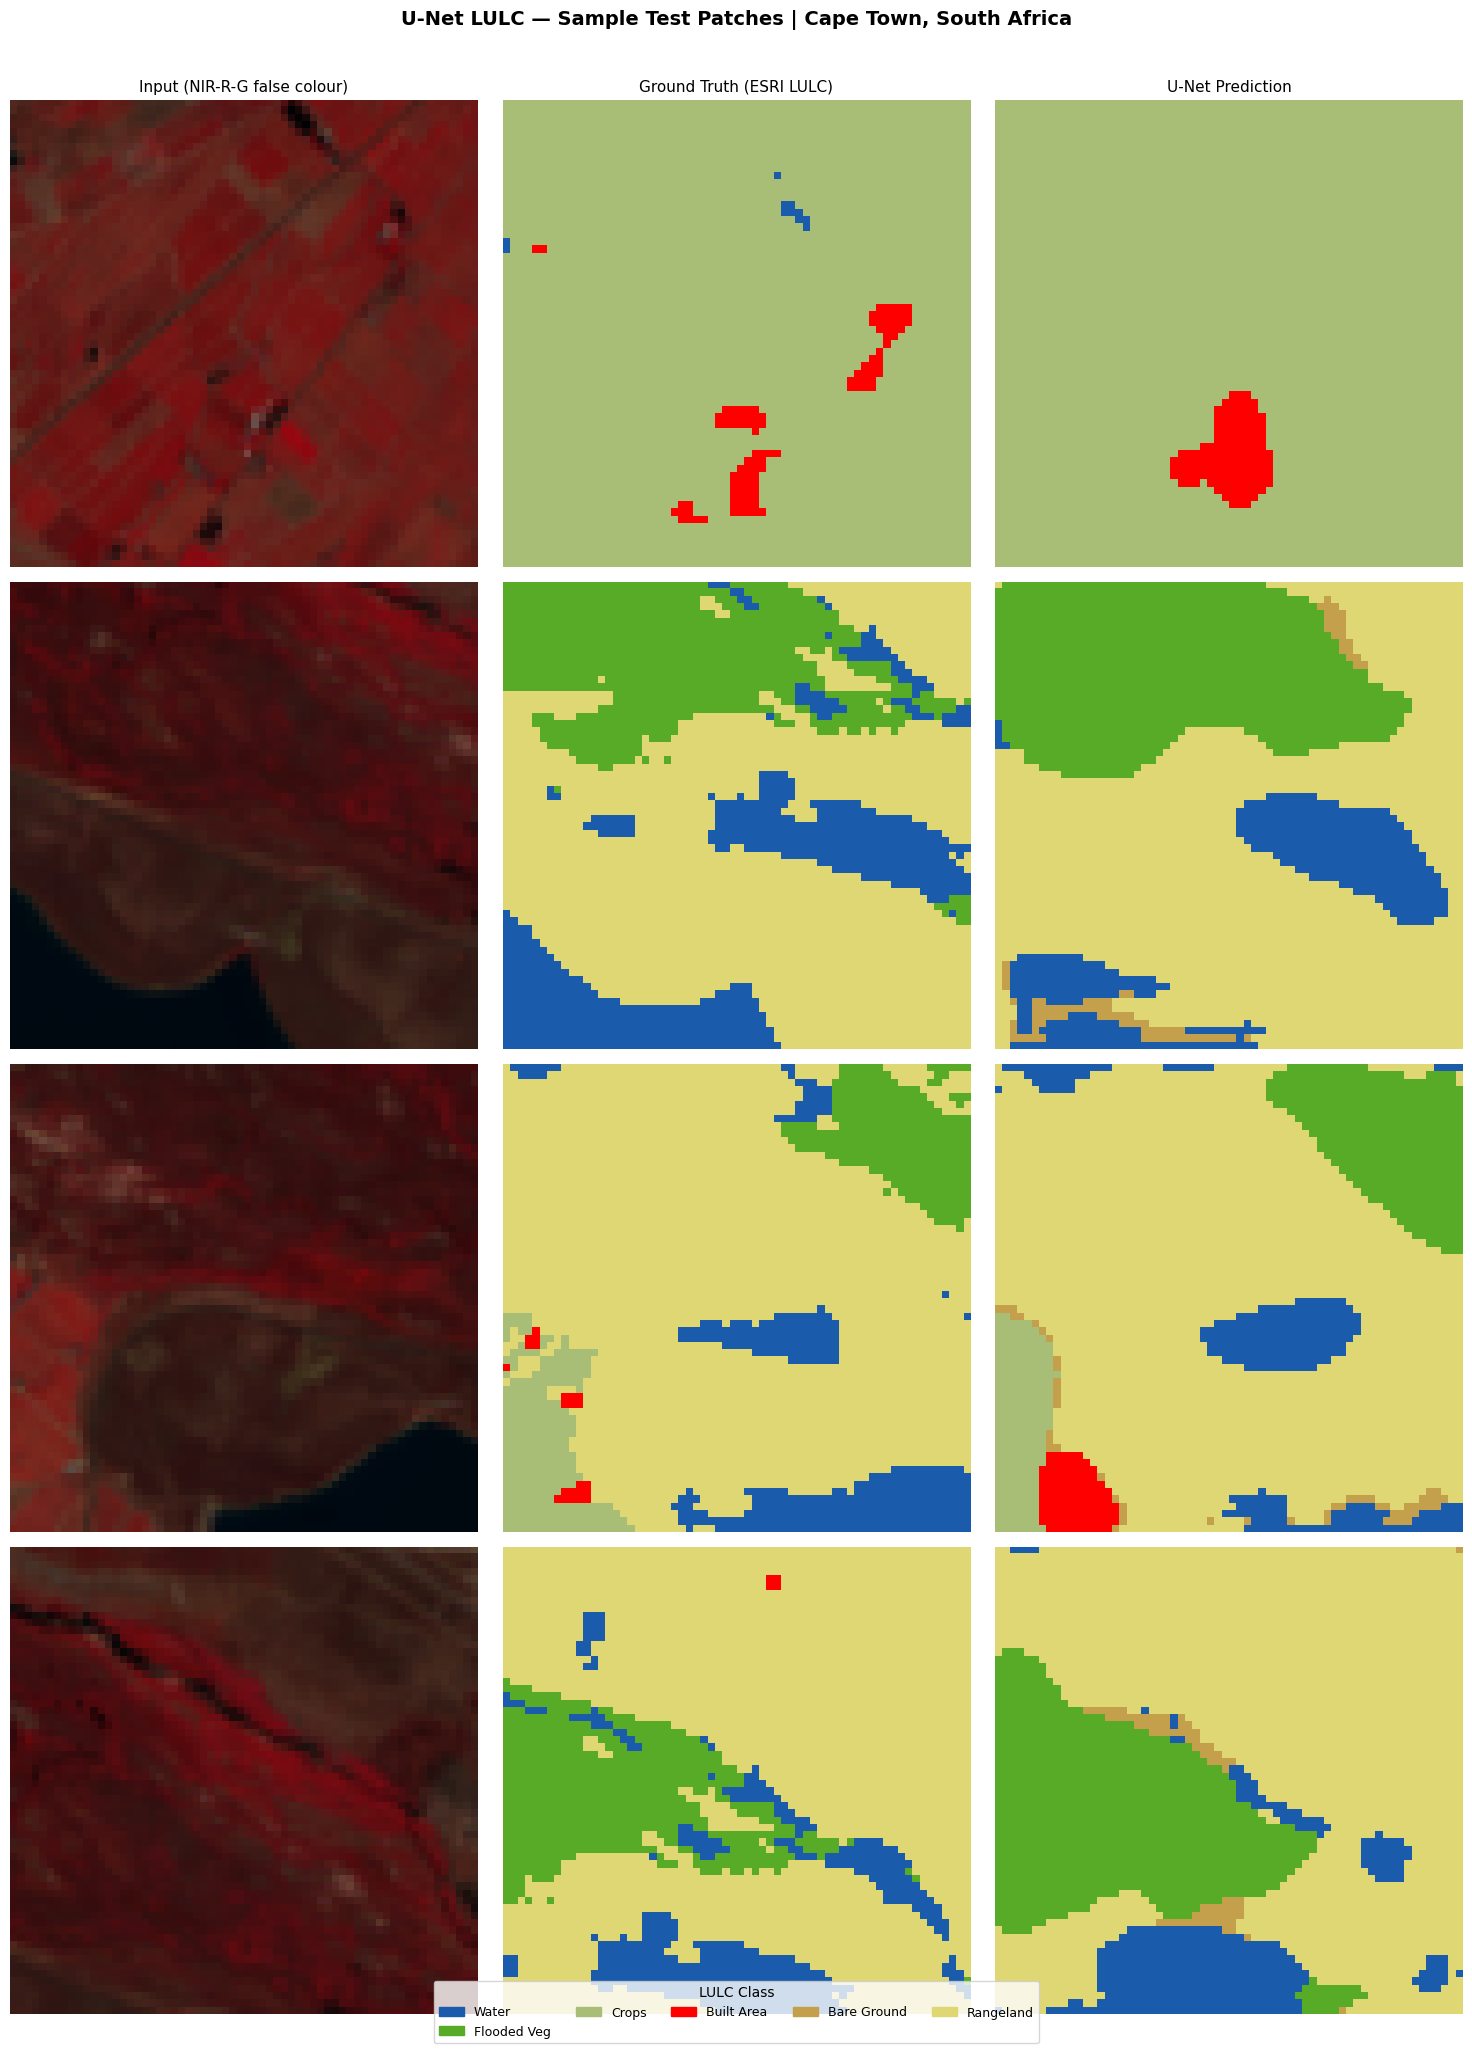

In [33]:
sample_idx = np.random.choice(len(test_ds), 4, replace=False)

fig, axes = plt.subplots(4, 3, figsize=(15, 20))
axes[0, 0].set_title('Input (NIR-R-G false colour)', fontsize=11)
axes[0, 1].set_title('Ground Truth (ESRI LULC)',     fontsize=11)
axes[0, 2].set_title('U-Net Prediction',             fontsize=11)

model.eval()
with torch.no_grad():
    for row, si in enumerate(sample_idx):
        X_s, Y_s = test_ds[si]
        logit    = model(X_s.unsqueeze(0).to(device))
        pred_s   = logit.argmax(dim=1).squeeze().cpu().numpy()

        img_np   = X_s.numpy().transpose(1, 2, 0)  # (H, W, 7)
        nir_ch  = img_np[:, :, 3] * stds[3] + means[3]
        red_ch  = img_np[:, :, 2] * stds[2] + means[2]
        grn_ch  = img_np[:, :, 1] * stds[1] + means[1]
        false_c = np.dstack([
            np.clip(nir_ch, 0, 1),
            np.clip(red_ch, 0, 1),
            np.clip(grn_ch, 0, 1)
        ])

        axes[row, 0].imshow(false_c)
        axes[row, 0].axis('off')
        axes[row, 1].imshow(Y_s.numpy(), cmap=cmap, norm=norm, interpolation='nearest')
        axes[row, 1].axis('off')
        axes[row, 2].imshow(pred_s,      cmap=cmap, norm=norm, interpolation='nearest')
        axes[row, 2].axis('off')

fig.legend(handles=patches, loc='lower center', ncol=min(N_CLS, 5),  # 'patches' defined in Cell 8
           fontsize=9, title='LULC Class', title_fontsize=10,
           bbox_to_anchor=(0.5, -0.01))
plt.suptitle('U-Net LULC — Sample Test Patches | Cape Town, South Africa',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/10_patch_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## Cell 26 — Full-Scene LULC Prediction Map

Full-scene inference: 100%|██████████| 23/23 [00:18<00:00,  1.24it/s]


Full-scene prediction shape: (242, 476)


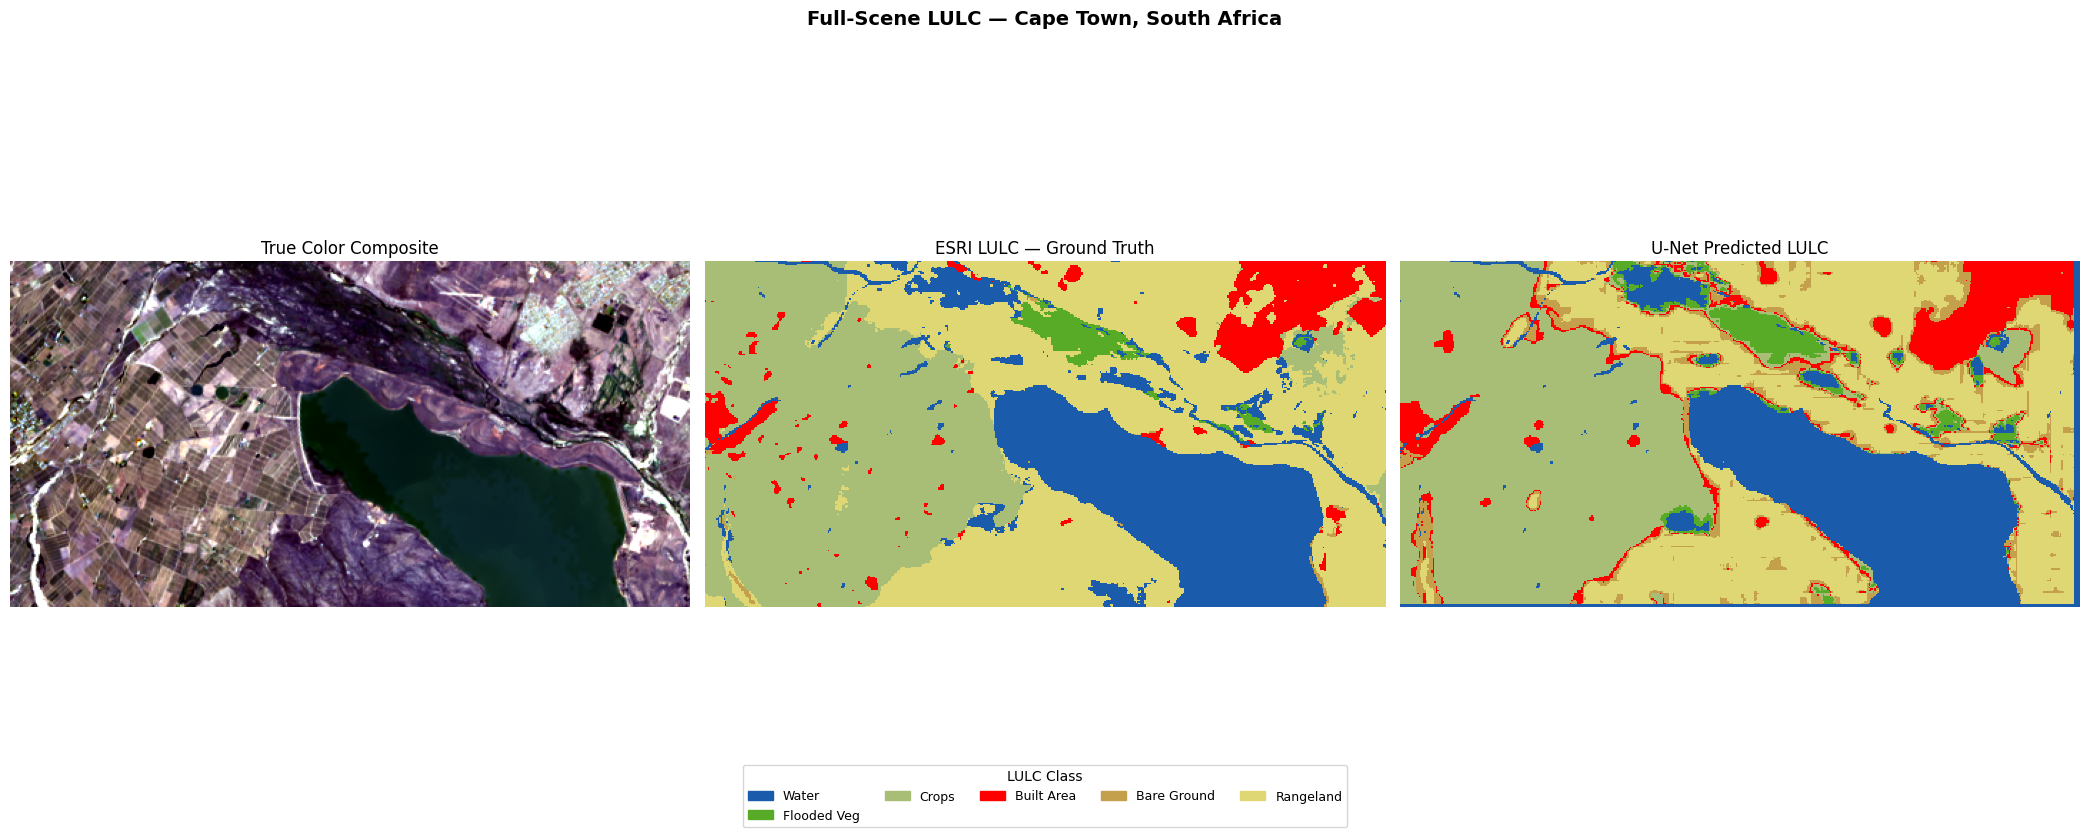

In [39]:
pred_map  = np.zeros((H_ls, W_ls), dtype=np.float32)
count_map = np.zeros((H_ls, W_ls), dtype=np.float32)

model.eval()
with torch.no_grad():
    for r in tqdm(range(0, H_ls - P_SZ + 1, STRIDE), desc='Full-scene inference'):
        for c in range(0, W_ls - P_SZ + 1, STRIDE):
            patch      = X_full[r:r+P_SZ, c:c+P_SZ, :].astype(np.float32)
            patch_norm = (patch - means) / stds
            x_t        = torch.from_numpy(
                             patch_norm.transpose(2, 0, 1)
                         ).unsqueeze(0).to(device)
            pred       = model(x_t).argmax(dim=1).squeeze().cpu().numpy().astype(np.float32)
            pred_map[r:r+P_SZ, c:c+P_SZ]  += pred
            count_map[r:r+P_SZ, c:c+P_SZ] += 1

unpredicted_mask = (count_map == 0)
count_map[unpredicted_mask] = 1

pred_map_final = np.round(pred_map / count_map).astype(np.int16)

water_idx = val_to_idx.get(2, 0)
pred_map_final[unpredicted_mask] = water_idx

pred_map_final[lrsz == -1] = water_idx

print(f'Full-scene prediction shape: {pred_map_final.shape}')

fig, axes = plt.subplots(1, 3, figsize=(21, 8))
axes[0].imshow(rgb)
axes[0].set_title('True Color Composite', fontsize=12)
axes[0].axis('off')

axes[1].imshow(lrsz, cmap=cmap, norm=norm, interpolation='nearest')
axes[1].set_title('ESRI LULC — Ground Truth', fontsize=12)
axes[1].axis('off')

axes[2].imshow(pred_map_final, cmap=cmap, norm=norm, interpolation='nearest')
axes[2].set_title('U-Net Predicted LULC', fontsize=12)
axes[2].axis('off')

fig.legend(handles=patches, loc='lower center', ncol=min(N_CLS, 5),
           fontsize=9, title='LULC Class', title_fontsize=10,
           bbox_to_anchor=(0.5, -0.02))
plt.suptitle('Full-Scene LULC — Cape Town, South Africa', fontsize=14,
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/11_full_scene_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## Cell 27 — Summary Metrics Table

In [37]:
summary_df = pd.DataFrame({
    'Class':    cnames,
    'F1 Score': np.round(f1_per_class, 4),
    'IoU':      np.round(iou_scores,   4),
})
summary_df.loc[len(summary_df)] = ['Macro / mIoU (excl. Bare Ground)',
                                    round(f1_macro, 4),
                                    round(mIoU, 4)]
summary_df.loc[len(summary_df)] = ['Weighted mIoU (excl. Bare Ground)',
                                    round(f1_weighted, 4),
                                    round(mIoU_weighted, 4)]
print(summary_df.to_string(index=False))
summary_df.to_csv(f'{OUT_DIR}/metrics_summary.csv', index=False)

print(f'\n All outputs saved to: {OUT_DIR}')
print('\nOutput files:')
for fname in sorted(os.listdir(OUT_DIR)):
    size = os.path.getsize(os.path.join(OUT_DIR, fname)) / 1024
    print(f'  {fname:<45s} {size:7.1f} KB')

                            Class  F1 Score    IoU
                            Water    0.5368 0.4242
                      Flooded Veg    0.7748 0.6535
                            Crops    0.9563 0.9246
                       Built Area    0.7771 0.6454
                      Bare Ground    0.0292 0.0295
                        Rangeland    0.8737 0.8056
 Macro / mIoU (excl. Bare Ground)    0.5640 0.6907
Weighted mIoU (excl. Bare Ground)    0.8516 0.8318

 All outputs saved to: /kaggle/working/capetown_lulc

Output files:
  01_true_color.png                               427.6 KB
  02_esri_lulc.png                                 83.7 KB
  03_ndvi.png                                     985.7 KB
  04_patch_locations.png                          621.4 KB
  05_training_curves.png                          140.4 KB
  06_confusion_matrix.png                          95.2 KB
  07_f1_scores.png                                 50.8 KB
  08_iou_scores.png                                70.0 KB
